In [21]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [51]:
smoothed_data = pd.read_csv('smoothed_close_prices.csv')

In [52]:
# Δημιουργία καθυστερημένων τιμών (lags) για τη στήλη 'Smoothed Close Price'
for lag in range(1, 4):  # Δημιουργία 3 καθυστερημένων τιμών
    smoothed_data[f'smoothed_close_t-{lag}'] = smoothed_data['Smoothed Close Price'].shift(-lag)

smoothed_data.fillna(0, inplace=True)

smoothed_data.tail()

,Date,Close Price,Smoothed Close Price,smoothed_close_t-1,smoothed_close_t-2,smoothed_close_t-3
6295,1999-11-05,88.31,92.654273,92.536572,92.447301,92.387371
6296,1999-11-04,83.62,92.536572,92.447301,92.387371,92.357269
6297,1999-11-03,81.50,92.447301,92.387371,92.357269,0.000000
6298,1999-11-02,80.25,92.387371,92.357269,0.000000,0.000000
6299,1999-11-01,77.62,92.357269,0.000000,0.000000,0.000000


In [53]:
smoothed_data.head()

,Date,Close Price,Smoothed Close Price,smoothed_close_t-1,smoothed_close_t-2,smoothed_close_t-3
0,2024-11-13,225.12,227.971690,227.974233,227.979185,227.986327
1,2024-11-12,224.23,227.974233,227.979185,227.986327,227.995280
2,2024-11-11,224.23,227.979185,227.986327,227.995280,228.005576
3,2024-11-08,226.96,227.986327,227.995280,228.005576,228.016665
4,2024-11-07,227.48,227.995280,228.005576,228.016665,228.027903


In [54]:
smoothed_data['Date'] = pd.to_datetime(data['Date'])

# Χωρίζουμε τα δεδομένα σε εκπαίδευση και επικύρωση
validation_data = smoothed_data[smoothed_data['Date'].dt.year == 2024]  # Στοιχεία για επικύρωση (2024)
training_data = smoothed_data[smoothed_data['Date'].dt.year < 2024]     # Στοιχεία για εκπαίδευση (προηγούμενα έτη)

# Ορισμός χαρακτηριστικών και στόχου
X_train = training_data[['smoothed_close_t-1', 'smoothed_close_t-2', 'smoothed_close_t-3']]
y_train = training_data['Smoothed Close Price']

X_val = validation_data[['smoothed_close_t-1', 'smoothed_close_t-2', 'smoothed_close_t-3']]
y_val = validation_data['Smoothed Close Price']

# Δημιουργία του μοντέλου γραμμικής παλινδρόμησης και εκπαίδευση
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [55]:
# Προβλέψεις στο σύνολο επικύρωσης
predictions = model.predict(X_val)

# Πρόβλεψη στο σύνολο εκπαίδευσης 
y_pred_train = model.predict(X_train)

In [56]:
# Υπολογισμός των μετρικών
mse_train = mean_squared_error(y_train, y_pred_train)
mse_val = mean_squared_error(y_val, predictions)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_val = mean_absolute_error(y_val, predictions)

print("Training MSE:", mse_train)
print("Validation MSE:", mse_val)
print("Training MAE:", mae_train)
print("Validation MAE:", mae_val)

Training MSE: 1.864074706293274
Validation MSE: 0.022195458218206607
Training MAE: 0.20686713801671563
Validation MAE: 0.11279556169774814


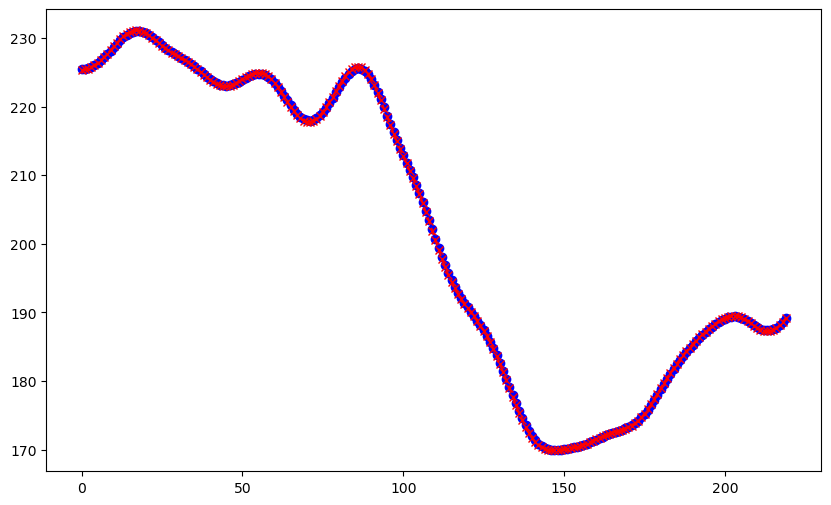

In [14]:
import matplotlib.pyplot as plt

# Γραφική απεικόνιση με πραγματικές και προβλεπόμενες τιμές στο σύνολο επικύρωσης
plt.figure(figsize=(10, 6))
plt.plot(y_val.reset_index(drop=True), label='Actual Values', color='blue', marker='o')
plt.plot(predictions, label='Predicted Values', color='red', linestyle='--', marker='x')

## Prediction

In [15]:
# παίρνουμε τις 3 τε΄λευταίεσ closing prices 
last_3_prices = data['Smoothed Close Price'].head(3).values  

if len(last_3_prices) >= 3:
    features = last_3_prices[-3:]  
else:
    raise ValueError("Not enough data to create features for prediction.")

# προετοιμασία των features για prediction 
X_next = pd.DataFrame([features], columns=['smoothed_close_t-1', 'smoothed_close_t-2', 'smoothed_close_t-3'])

# πρόβλεψη closing τιμής της επόμενης ημέρας
predicted_price = model.predict(X_next)

# Αποτέλεσμα πρόβλεψης
print(f"Predicted Close Price for next day: {predicted_price[0]}")

Predicted Close Price for next day: 225.31719984374374
